In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score



plt.rcParams['font.family'] = 'Malgun Gothic'   # 윈도우
plt.rcParams['axes.unicode_minus'] = False

# 머신러닝 - 군집화(K-Means)

In [37]:
df_z = pd.read_csv('../../data/busan_youth_zscore_only.csv')
# merged = pd.read_cs/v('../../../data/busan_youth_zscore_only.csv', index_col='Unnamed: 0')
df_z.head()

,연도,행정구역,청년_19_29_증감률(%)_z,청년_30_39_증감률(%)_z,상용월평균급여(원)_z,문화예술활동(건)_z,대학수(천명당)_z,문화기반시설수(십만명당)_z,기업밀도_z,연앙인구수(천명)_z,재정자립도(%)_z,지역내총생산(십억원)_z
0,2016,강원특별자치도,-0.119064,-0.284835,-0.600234,-0.205085,0.854703,1.549660,-0.387657,-0.455941,-1.188626,-0.520361
1,2016,경기도,0.014971,-0.045046,0.166934,0.680446,-0.923381,-0.598474,3.040583,2.946692,1.069933,2.677738
2,2016,경상남도,-0.359782,-0.291791,-0.012171,-0.117638,-0.652955,-0.214410,0.162636,0.105927,-0.370107,0.045773
3,2016,경상북도,-0.370028,-0.304519,0.161814,-0.351067,1.482685,0.118136,-0.025902,-0.100210,-0.975500,0.035230
4,2016,광주광역시,-0.426919,-0.547518,-0.674692,-0.262193,0.839705,-0.627009,-0.500104,-0.479118,0.209941,-0.563549


In [38]:
# 변수 분류
# 종속변수
y_cols = df_z[['청년_19_29_증감률(%)_z', '청년_30_39_증감률(%)_z']]

# 독립변수
x_cols = df_z[['상용월평균급여(원)_z', '문화예술활동(건)_z', 
                '대학수(천명당)_z', '문화기반시설수(십만명당)_z', '기업밀도_z']]

# 독립변수(통계방식변경)
# x_cols_modify = df_z[['상용월평균급여(원)_z', '문화예술활동(건)_z', 
#                 '대학수(천명당)_z', '문화기반시설수(십만명당)_z', '기업밀도_z', '통계방식변경']]


# 통제변수(하나만 적용)
meta_cols = df_z[['재정자립도(%)_z']]
# meta_cols = df_z[['연앙인구수(천명)_z', '재정자립도(%)_z', '지역내총생산(십억원)_z']]

# Group by
group_cols = df_z[['연도', '행정구역']]

In [39]:
df_z.columns

Index(['연도', '행정구역', '청년_19_29_증감률(%)_z', '청년_30_39_증감률(%)_z', '상용월평균급여(원)_z',
       '문화예술활동(건)_z', '대학수(천명당)_z', '문화기반시설수(십만명당)_z', '기업밀도_z', '연앙인구수(천명)_z',
       '재정자립도(%)_z', '지역내총생산(십억원)_z'],
      dtype='object')

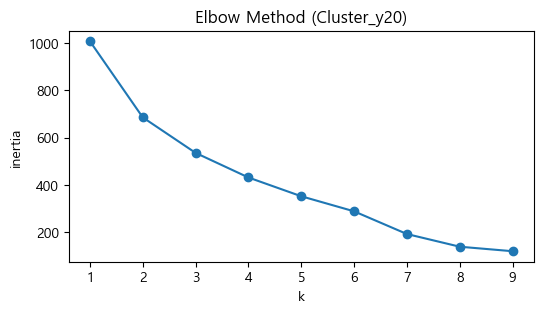

y20 군집화 완료: Cluster_y20
y20 실루엣 점수: 0.4817


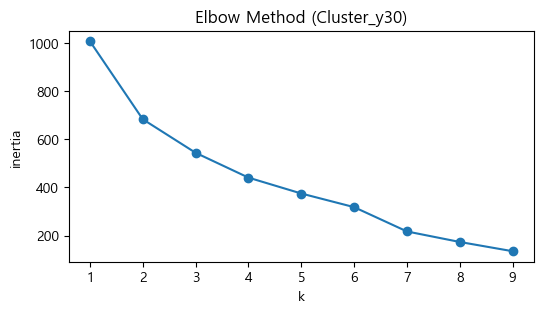

y30 군집화 완료: Cluster_y30
y30 실루엣 점수: 0.4843


In [40]:
# K means 군집화
# 0) y 컬럼명

y20 = "청년_19_29_증감률(%)_z"
y30 = "청년_30_39_증감률(%)_z"


# 1) feature 컬럼 리스트

feature_cols_y20 = x_cols.columns.tolist() + meta_cols.columns.tolist() + [y20]
feature_cols_y30 = x_cols.columns.tolist() + meta_cols.columns.tolist() + [y30]


def run_kmeans_elbow_silhouette(df, feature_cols, label_col,
                               k_final=3, k_min=1, k_max=9, random_state=42,
                               show_elbow=True):
    # 1) KMeans 입력 행렬
    X = df[feature_cols].copy()
    X = X.replace([np.inf, -np.inf], np.nan).dropna()

    # 2) 엘보우
    if show_elbow:
        inertia = []
        K_range = range(k_min, k_max + 1)
        for k in K_range:
            km = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
            km.fit(X)
            inertia.append(km.inertia_)

        plt.figure(figsize=(6, 3))
        plt.plot(list(K_range), inertia, marker='o')
        plt.title(f'Elbow Method ({label_col})')
        plt.xlabel("k")
        plt.ylabel("inertia")
        plt.show()

    # 3) 최종 군집
    km_final = KMeans(n_clusters=k_final, random_state=random_state, n_init="auto")
    labels = km_final.fit_predict(X)

    # 4) df에 라벨 붙이기
    df.loc[X.index, label_col] = labels

    # 5) 실루엣 점수 (k>=2, 샘플수가 k보다 충분히 커야 함)
    sil = None
    if k_final >= 2 and X.shape[0] > k_final:
        sil = silhouette_score(X, labels)

    return df, km_final, X, labels, sil


# def plot_cluster_heatmap_zscore(df, label_col, target_cols, title=None):

#     # 1) 필요한 컬럼 존재 확인
#     need = [label_col] + list(target_cols)
#     missing = [c for c in need if c not in df.columns]
#     if missing:
#         raise ValueError(f"df에 없는 컬럼: {missing}")

#     # 2) 라벨이 붙은 행만 사용(결측 라벨 제거)
#     tmp = df.dropna(subset=[label_col]).copy()
#     tmp[label_col] = tmp[label_col].astype(int)

#     # 3) Z-Score(클러스터 평균 - 전체 평균) / 전체 표준편차
#     cluster_z = (
#         tmp.groupby(label_col)[target_cols].mean()
#         .sub(tmp[target_cols].mean(), axis=1)
#         .div(tmp[target_cols].std(ddof=0), axis=1)
#     )

#     plt.figure(figsize=(8, 5))
#     sns.heatmap(cluster_z, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
#     plt.title(title if title else f'클러스터별 특징(Z-Score) 히트맵: {label_col}')
#     plt.xlabel("지표")
#     plt.ylabel("클러스터")
#     plt.show()

def plot_cluster_heatmap_mean(df, label_col, target_cols, title=None):
    tmp = df.dropna(subset=[label_col]).copy()
    tmp[label_col] = tmp[label_col].astype(int)

    cluster_z = tmp.groupby(label_col)[target_cols].mean()

    plt.figure(figsize=(8, 5))
    sns.heatmap(cluster_z, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
    plt.title(title if title else f'클러스터별 평균(이미 Z): {label_col}')
    plt.xlabel("지표")
    plt.ylabel("클러스터")
    plt.show()

    # return cluster_mean
    return cluster_z



# 2) (A) y20 군집 + 실루엣

df_z, km_y20, X20, labels_y20, sil_y20 = run_kmeans_elbow_silhouette(
    df=df_z,
    feature_cols=feature_cols_y20,
    label_col="Cluster_y20",
    k_final=2,
    show_elbow=True
)

print("y20 군집화 완료: Cluster_y20")
print(f"y20 실루엣 점수: {sil_y20:.4f}" if sil_y20 is not None else "y20 실루엣 점수: 계산 불가")


# 3) (B) y30 군집 + 실루엣

df_z, km_y30, X30, labels_y30, sil_y30 = run_kmeans_elbow_silhouette(
    df=df_z,
    feature_cols=feature_cols_y30,
    label_col="Cluster_y30",
    k_final=2,
    show_elbow=True
) 

print("y30 군집화 완료: Cluster_y30")
print(f"y30 실루엣 점수: {sil_y30:.4f}" if sil_y30 is not None else "y30 실루엣 점수: 계산 불가")


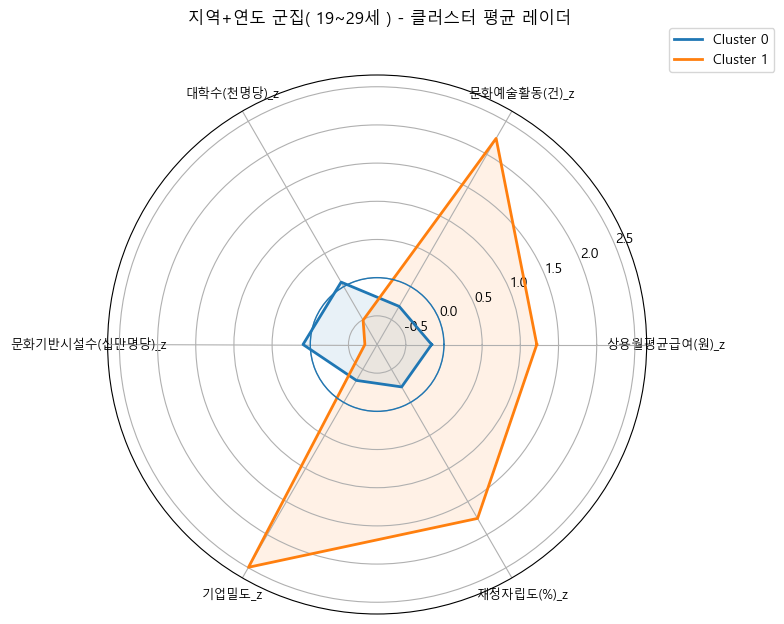

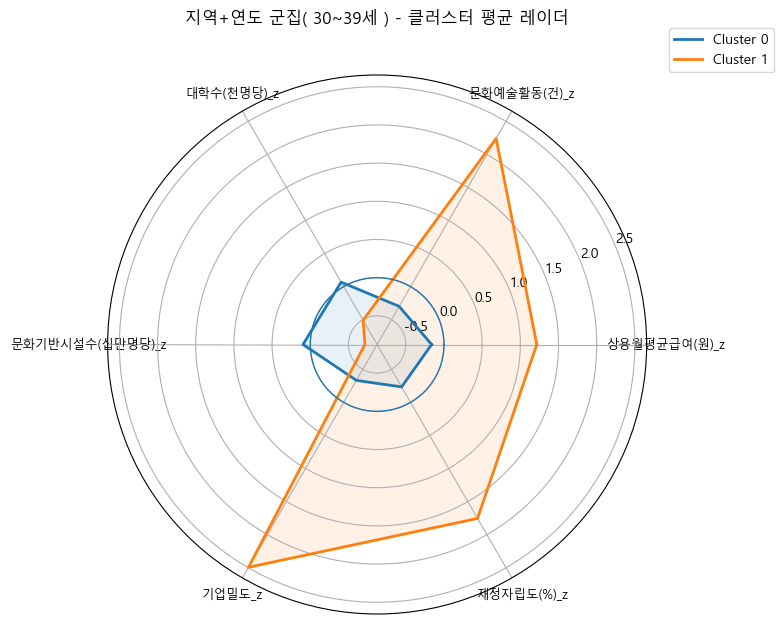

In [41]:
# 군집결과 레이더차트 그리기(시각화) - 지역+연도별 

import numpy as np
import matplotlib.pyplot as plt

def plot_cluster_radar(df, label_col, feature_cols,
                       exclude_cols=None,
                       agg="mean",
                       normalize="zscore_overall",  # "zscore_overall" or "none"
                       title=None,
                       figsize=(7, 7)):
    """
    클러스터별 레이더차트
    - df: df_z
    - label_col: "Cluster_y20" or "Cluster_y30"
    - feature_cols: feature_cols_y20 / feature_cols_y30
    - exclude_cols: 레이더에서 뺄 컬럼 (보통 y는 제외 추천)
    - agg: "mean" (클러스터 평균 기준)
    - normalize:
        - "zscore_overall": (클러스터 평균 - 전체 평균) / 전체 표준편차  -> 비교가 선명해짐
        - "none": 클러스터 평균값 그대로(이미 z값이면 이게 더 깔끔)
    """

    # 1) target_cols 확정
    target_cols = list(feature_cols)
    if exclude_cols:
        target_cols = [c for c in target_cols if c not in set(exclude_cols)]

    # 2) 존재 체크
    need = [label_col] + target_cols
    missing = [c for c in need if c not in df.columns]
    if missing:
        raise ValueError(f"df에 없는 컬럼: {missing}")

    # 3) 라벨 있는 행만 사용 + 숫자형만 사용
    tmp = df.dropna(subset=[label_col]).copy()
    tmp[label_col] = tmp[label_col].astype(int)

    num_cols = tmp[target_cols].select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols) < 3:
        raise ValueError("레이더차트는 최소 3개 이상의 숫자형 변수 필요")

    # 4) 클러스터 요약치(평균)
    if agg == "mean":
        cluster_stat = tmp.groupby(label_col)[num_cols].mean()
    else:
        raise ValueError("agg는 현재 'mean'만 지원")

    # 5) 정규화(선택)
    if normalize == "zscore_overall":
        overall_mean = tmp[num_cols].mean()
        overall_std = tmp[num_cols].std(ddof=0).replace(0, np.nan)
        radar_df = (cluster_stat - overall_mean) / overall_std
        radar_df = radar_df.fillna(0)
    elif normalize == "none":
        radar_df = cluster_stat.copy()
    else:
        raise ValueError("normalize는 'zscore_overall' 또는 'none'만 가능")

    # 6) 레이더 각도 세팅
    labels = radar_df.columns.tolist()
    n = len(labels)
    angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist()
    angles += angles[:1]

    # 7) 플롯
    fig = plt.figure(figsize=figsize)
    ax = plt.subplot(111, polar=True)

    for cl in radar_df.index:
        values = radar_df.loc[cl].values.tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=f"Cluster {cl}")
        ax.fill(angles, values, alpha=0.10)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9)

    # 0 기준선이 보이도록(정규화 선택 시 유용)
    ax.axhline(0, linewidth=1)

    plt.title(title if title else f"클러스터별 레이더차트: {label_col}", y=1.08)
    plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1.10))
    plt.show()

    return radar_df


# 레이더차트 그리기
# 보통 y는 레이더에서 제외 추천 (원인 X+통제 패턴만 보려고)
radar_y20 = plot_cluster_radar(
    df=df_z,
    label_col="Cluster_y20",
    feature_cols=feature_cols_y20,
    exclude_cols=[y20],                 #  y 제외
    normalize="zscore_overall",         #  전체대비 얼마나 튀는지 강조
    title=" 지역+연도 군집( 19~29세 ) - 클러스터 평균 레이더"
)

radar_y30 = plot_cluster_radar(
    df=df_z,
    label_col="Cluster_y30",
    feature_cols=feature_cols_y30,
    exclude_cols=[y30],                 #  y 제외
    normalize="zscore_overall",
    title="지역+연도 군집( 30~39세 ) - 클러스터 평균 레이더"
)


In [42]:
# # y20 기준
# region_cluster_y20 = (
#     df_z
#     .dropna(subset=["Cluster_y20"])
#     .groupby(["행정구역", "Cluster_y20"])
#     .size()
#     .unstack(fill_value=0)
#     .sort_index()
# )

# print(region_cluster_y20)


In [43]:
# import pandas as pd

# # 1) 지역×클러스터 빈도표 만들기
# tbl = (df_z.dropna(subset=["Cluster_y20"])
#        .groupby(["행정구역", "Cluster_y20"])
#        .size()
#        .unstack(fill_value=0)
#        .sort_index())
# tbl.columns = tbl.columns.astype(int)

# # 2) 예쁘게 스타일링
# (tbl.style
#  .format("{:,.0f}")                       # 숫자 포맷
#  .background_gradient(axis=None)          # 전체 그라데이션
#  .set_caption("지역별 Cluster_y20 분포(빈도)")
# )


In [44]:
# # 1) 지역×클러스터 빈도표 만들기
# tbl = (df_z.dropna(subset=["Cluster_y30"])
#        .groupby(["행정구역", "Cluster_y30"])
#        .size()
#        .unstack(fill_value=0)
#        .sort_index())
# tbl.columns = tbl.columns.astype(int)

# # 2) 예쁘게 스타일링
# (tbl.style
#  .format("{:,.0f}")                       # 숫자 포맷
#  .background_gradient(axis=None)          # 전체 그라데이션
#  .set_caption("지역별 Cluster_y30 분포(빈도)")
# )


In [45]:
# 클러스터 구분 표(2016년~2024년 발생빈도 표시)
import pandas as pd
from IPython.display import display

def make_cluster_table(df, label_col, caption):
    tbl = (df.dropna(subset=[label_col])
           .groupby(["행정구역", label_col])
           .size()
           .unstack(fill_value=0)
           .sort_index())

    # 0.0, 1.0 같은 float 컬럼명 -> int로
    tbl.columns = tbl.columns.astype(int)

    sty = (tbl.style
           .format("{:,.0f}")
           .background_gradient(axis=None)
           .set_caption(caption))

    return sty

# y20 표
sty_y20 = make_cluster_table(df_z, "Cluster_y20", "지역별 Cluster_y20 분포(빈도)")

# y30 표
sty_y30 = make_cluster_table(df_z, "Cluster_y30", "지역별 Cluster_y30 분포(빈도)")

# 같이 출력
display(sty_y20)
display(sty_y30)


Cluster_y20,0,1
행정구역,,
강원특별자치도,9,0
경기도,0,9
경상남도,9,0
경상북도,9,0
광주광역시,9,0
대구광역시,9,0
대전광역시,9,0
부산광역시,9,0
서울특별시,0,9


Cluster_y30,0,1
행정구역,,
강원특별자치도,9,0
경기도,0,9
경상남도,9,0
경상북도,9,0
광주광역시,9,0
대구광역시,9,0
대전광역시,9,0
부산광역시,9,0
서울특별시,0,9


--------

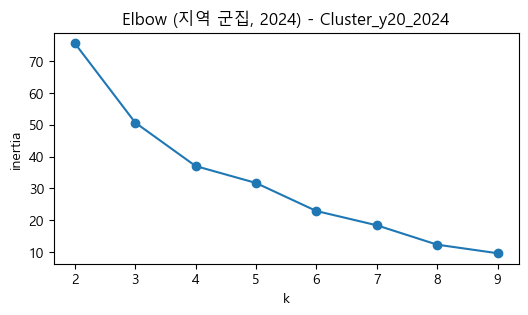

  연도    행정구역  Cluster_y20_2024
2024   대전광역시               0.0
2024   인천광역시               0.0
2024   울산광역시               0.0
2024 세종특별자치시               0.0
2024    충청남도               0.0
2024 강원특별자치도               1.0
2024    경상북도               1.0
2024    경상남도               1.0
2024 전북특별자치도               1.0
2024   부산광역시               1.0
2024   광주광역시               1.0
2024   대구광역시               1.0
2024 제주특별자치도               1.0
2024    전라남도               1.0
2024    충청북도               1.0
2024     경기도               2.0
2024   서울특별시               2.0
Silhouette(2024, y20): 0.2723


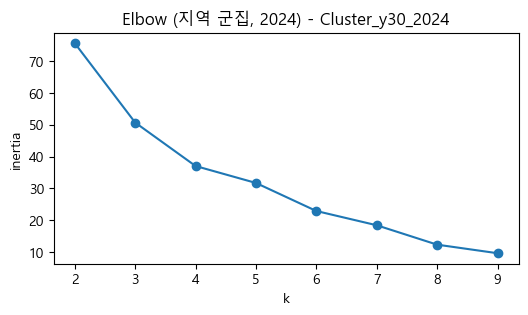

  연도    행정구역  Cluster_y30_2024
2024   대전광역시               0.0
2024   인천광역시               0.0
2024   울산광역시               0.0
2024 세종특별자치시               0.0
2024    충청남도               0.0
2024 강원특별자치도               1.0
2024    경상북도               1.0
2024    경상남도               1.0
2024 전북특별자치도               1.0
2024   부산광역시               1.0
2024   광주광역시               1.0
2024   대구광역시               1.0
2024 제주특별자치도               1.0
2024    전라남도               1.0
2024    충청북도               1.0
2024     경기도               2.0
2024   서울특별시               2.0
Silhouette(2024, y30): 0.2723


In [46]:
# 군집화2 - 지역별(2024년 기준)
# 0) 타겟 컬럼명
y20 = "청년_19_29_증감률(%)_z"
y30 = "청년_30_39_증감률(%)_z"

# 1) feature 리스트 (지역 군집에서도 동일하게 사용 가능)
feature_cols_y20 = x_cols.columns.tolist() + meta_cols.columns.tolist() + [y20]
feature_cols_y30 = x_cols.columns.tolist() + meta_cols.columns.tolist() + [y30]

def run_region_kmeans_one_year(df, year, feature_cols, label_col,
                              year_col="연도", region_col="행정구역",
                              k_final=3, k_min=2, k_max=9, random_state=42,
                              show_elbow=True):
    # 1) 연도 고정 => 이제 행(row)은 "지역"들
    df_y = df[df[year_col] == year].copy()

    # 2) KMeans 입력 X (숫자만, 결측 제거)
    X = (df_y[feature_cols]
         .replace([np.inf, -np.inf], np.nan)
         .dropna())

    # 3) 엘보우
    if show_elbow:
        Ks = [k for k in range(k_min, k_max + 1) if k < len(X)]
        inertia = []
        for k in Ks:
            km = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
            km.fit(X)
            inertia.append(km.inertia_)

        plt.figure(figsize=(6, 3))
        plt.plot(Ks, inertia, marker="o")
        plt.title(f"Elbow (지역 군집, {year}) - {label_col}")
        plt.xlabel("k")
        plt.ylabel("inertia")
        plt.show()

    # 4) 최종 군집 + 실루엣
    km_final = KMeans(n_clusters=k_final, random_state=random_state, n_init="auto")
    labels = km_final.fit_predict(X)

    sil = None
    if k_final >= 2 and len(X) > k_final:
        sil = silhouette_score(X, labels)

    # 5) 라벨 붙이기 (해당 연도 df에만)
    df_y[label_col] = np.nan
    df_y.loc[X.index, label_col] = labels

    # 6) 결과를 보기 좋게 (지역, 클러스터)
    result = df_y[[year_col, region_col, label_col]].sort_values(label_col)

    return df_y, result, km_final, X, labels, sil


# 실행 예시: 2024년 지역 군집(y20 기준)

df_2024_y20, result_2024_y20, km_2024_y20, X_2024_y20, labels_2024_y20, sil_2024_y20 = run_region_kmeans_one_year(
    df=df_z,
    year=2024,
    feature_cols=feature_cols_y20,
    label_col="Cluster_y20_2024",
    k_final=3,          # 여기 숫자가 "지역 군집 개수"
    show_elbow=True
)

print(result_2024_y20.to_string(index=False))
print(f"Silhouette(2024, y20): {sil_2024_y20:.4f}" if sil_2024_y20 is not None else "Silhouette: 계산 불가")


# 실행 예시: 2024년 지역 군집(y30 기준)

df_2024_y30, result_2024_y30, km_2024_y30, X_2024_y30, labels_2024_y30, sil_2024_y30 = run_region_kmeans_one_year(
    df=df_z,
    year=2024,
    feature_cols=feature_cols_y20,
    label_col="Cluster_y30_2024",
    k_final=3,          # 여기 숫자가 "지역 군집 개수"
    show_elbow=True
)

print(result_2024_y30.to_string(index=False))
print(f"Silhouette(2024, y30): {sil_2024_y30:.4f}" if sil_2024_y30 is not None else "Silhouette: 계산 불가")

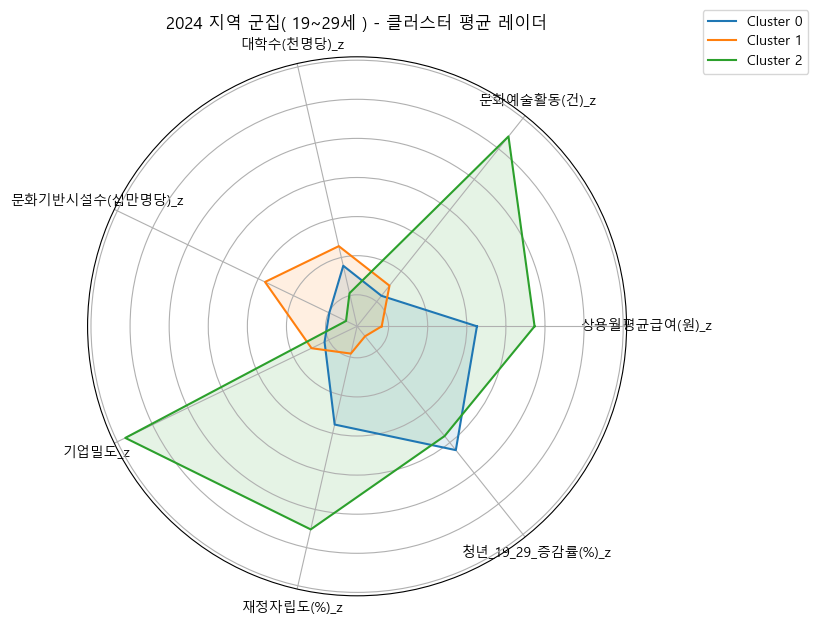

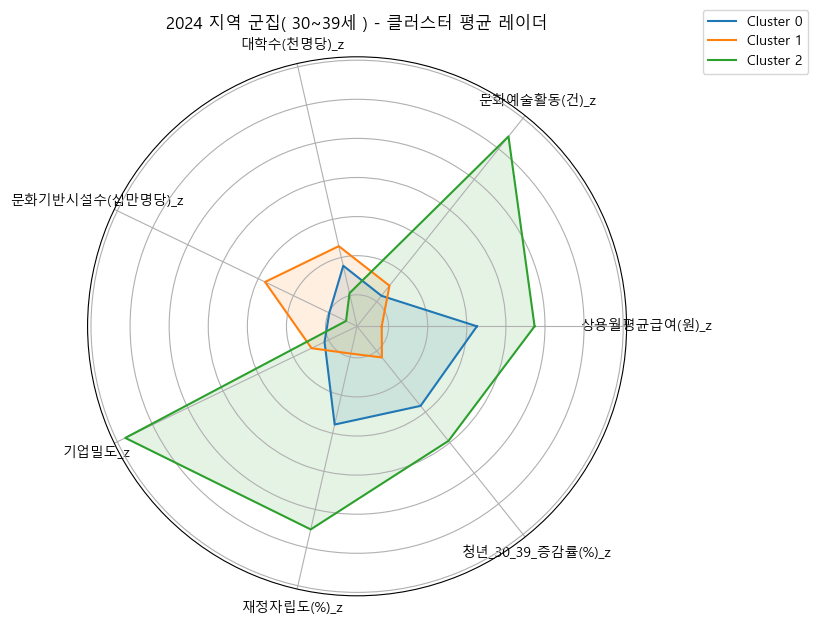

In [47]:
# 레이더차트 그리기 

def radar_cluster_mean(df_year, cluster_col, feature_cols, title=None, top_k=8):
    # 1) 라벨 있는 행만
    tmp = df_year.dropna(subset=[cluster_col]).copy()
    tmp[cluster_col] = tmp[cluster_col].astype(int)

    # 2) 변수 너무 많으면 분산 큰 변수 top_k만
    use_cols = feature_cols
    if top_k is not None and len(feature_cols) > top_k:
        use_cols = tmp[feature_cols].var().sort_values(ascending=False).head(top_k).index.tolist()

    # 3) 클러스터별 평균
    radar_df = tmp.groupby(cluster_col)[use_cols].mean()

    # 4) 레이더 그리기
    labels = radar_df.columns.tolist()
    n = len(labels)

    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    angles = np.r_[angles, angles[0]]

    plt.figure(figsize=(7, 7))
    ax = plt.subplot(111, polar=True)

    for c, row in radar_df.iterrows():
        values = row.values
        values = np.r_[values, values[0]]
        ax.plot(angles, values, label=f"Cluster {c}")
        ax.fill(angles, values, alpha=0.12)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels([])

    plt.title(title if title else f"Cluster mean radar: {cluster_col}", pad=20)
    plt.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
    plt.show()

    return radar_df

radar_mean_2024_y20 = radar_cluster_mean(
    df_year=df_2024_y20,
    cluster_col="Cluster_y20_2024",
    feature_cols=feature_cols_y20,
    title="2024 지역 군집( 19~29세 ) - 클러스터 평균 레이더",
    top_k=8
)

radar_mean_2024_y30 = radar_cluster_mean(
    df_year=df_2024_y30,
    cluster_col="Cluster_y30_2024",
    feature_cols=feature_cols_y30,
    title="2024 지역 군집( 30~39세 ) - 클러스터 평균 레이더",
    top_k=8
)


------------------

# 머신러닝2 - 회귀분석

In [48]:
df_z

,연도,행정구역,청년_19_29_증감률(%)_z,청년_30_39_증감률(%)_z,상용월평균급여(원)_z,문화예술활동(건)_z,대학수(천명당)_z,문화기반시설수(십만명당)_z,기업밀도_z,연앙인구수(천명)_z,재정자립도(%)_z,지역내총생산(십억원)_z,Cluster_y20,Cluster_y30
0,2016,강원특별자치도,-0.119064,-0.284835,-0.600234,-0.205085,0.854703,1.549660,-0.387657,-0.455941,-1.188626,-0.520361,0.0,0.0
1,2016,경기도,0.014971,-0.045046,0.166934,0.680446,-0.923381,-0.598474,3.040583,2.946692,1.069933,2.677738,1.0,1.0
2,2016,경상남도,-0.359782,-0.291791,-0.012171,-0.117638,-0.652955,-0.214410,0.162636,0.105927,-0.370107,0.045773,0.0,0.0
3,2016,경상북도,-0.370028,-0.304519,0.161814,-0.351067,1.482685,0.118136,-0.025902,-0.100210,-0.975500,0.035230,0.0,0.0
4,2016,광주광역시,-0.426919,-0.547518,-0.674692,-0.262193,0.839705,-0.627009,-0.500104,-0.479118,0.209941,-0.563549,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,2024,전라남도,-0.518022,0.005958,-0.162273,-0.358235,0.406573,1.182580,-0.306634,-0.359256,-1.137119,-0.260644,0.0,0.0
149,2024,전북특별자치도,-0.972103,-0.271329,-0.882036,-0.251928,0.669217,0.598846,-0.265283,-0.374308,-1.201416,-0.468302,0.0,0.0
150,2024,제주특별자치도,-0.976313,-0.769400,-1.450222,-0.460300,-0.968725,2.406320,-0.679208,-0.692800,-0.442855,-0.690959,0.0,0.0
151,2024,충청남도,1.911852,0.311186,1.394857,-0.253783,0.610334,0.275757,-0.256486,-0.259994,-0.562780,0.000253,0.0,0.0


In [49]:
# 분석 
# df= pd.read_csv('../../data/busan_youth_v4.csv')
df = pd.read_csv('../../data/busan_youth_v4.csv', index_col='Unnamed: 0')
df

,연도,행정구역,연앙인구수(천명),재정자립도(%),통계방식변경,상용월평균급여(원),문화예술활동(건),대학수(천명당),문화기반시설수(십만명당),기업밀도,지역내총생산(십억원),청년_19_29_증감률(%),청년_30_39_증감률(%)
0,2016,강원특별자치도,1536.2750,22.40,0.0,3023906.0,1444.0,0.012368,13.734520,351.305988,44677.444,1.149646,-2.070627
1,2016,경기도,12509.4835,61.61,0.0,3328379.0,3925.0,0.006235,4.028943,2230.077238,433443.961,1.820153,-0.773010
2,2016,경상남도,3348.2515,36.61,0.0,3257296.0,1689.0,0.007168,5.764203,652.882347,113497.638,-0.054546,-2.108272
3,2016,경상북도,2683.4775,26.10,0.0,3326347.0,1035.0,0.014533,7.266690,549.557763,112216.094,-0.105801,-2.177146
4,2016,광주광역시,1461.5310,46.68,0.0,2994355.0,1284.0,0.012316,3.900020,289.682121,39427.386,-0.390397,-3.492136
...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,2024,전라남도,1792.3250,24.40,1.0,4034870.0,1438.0,0.010601,13.390429,504.474684,103970.897,-5.046648,-0.016089
149,2024,전북특별자치도,1741.6360,23.51,1.0,3736595.0,1839.0,0.011483,10.794448,537.972610,66792.381,-5.533847,-0.308514
150,2024,제주특별자치도,669.0510,34.01,1.0,3501134.0,1053.0,0.005979,18.832645,202.652238,26928.491,-5.538364,-0.833774
151,2024,충청남도,2126.6115,32.35,1.0,4680157.0,1832.0,0.011286,9.357610,545.099532,150681.268,-2.439551,0.305802


In [50]:
df_z

,연도,행정구역,청년_19_29_증감률(%)_z,청년_30_39_증감률(%)_z,상용월평균급여(원)_z,문화예술활동(건)_z,대학수(천명당)_z,문화기반시설수(십만명당)_z,기업밀도_z,연앙인구수(천명)_z,재정자립도(%)_z,지역내총생산(십억원)_z,Cluster_y20,Cluster_y30
0,2016,강원특별자치도,-0.119064,-0.284835,-0.600234,-0.205085,0.854703,1.549660,-0.387657,-0.455941,-1.188626,-0.520361,0.0,0.0
1,2016,경기도,0.014971,-0.045046,0.166934,0.680446,-0.923381,-0.598474,3.040583,2.946692,1.069933,2.677738,1.0,1.0
2,2016,경상남도,-0.359782,-0.291791,-0.012171,-0.117638,-0.652955,-0.214410,0.162636,0.105927,-0.370107,0.045773,0.0,0.0
3,2016,경상북도,-0.370028,-0.304519,0.161814,-0.351067,1.482685,0.118136,-0.025902,-0.100210,-0.975500,0.035230,0.0,0.0
4,2016,광주광역시,-0.426919,-0.547518,-0.674692,-0.262193,0.839705,-0.627009,-0.500104,-0.479118,0.209941,-0.563549,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,2024,전라남도,-0.518022,0.005958,-0.162273,-0.358235,0.406573,1.182580,-0.306634,-0.359256,-1.137119,-0.260644,0.0,0.0
149,2024,전북특별자치도,-0.972103,-0.271329,-0.882036,-0.251928,0.669217,0.598846,-0.265283,-0.374308,-1.201416,-0.468302,0.0,0.0
150,2024,제주특별자치도,-0.976313,-0.769400,-1.450222,-0.460300,-0.968725,2.406320,-0.679208,-0.692800,-0.442855,-0.690959,0.0,0.0
151,2024,충청남도,1.911852,0.311186,1.394857,-0.253783,0.610334,0.275757,-0.256486,-0.259994,-0.562780,0.000253,0.0,0.0


In [51]:
# 통계 int 변경 및 z score에 합치기
df_z_modify = df_z.copy()
df_z_modify['통계방식변경'] = df['통계방식변경'].astype(int)

# 인구 증감률 z-score -> 원자료 값 
# cluster 열 삭제
df_z_modify = df_z_modify.drop(columns=['청년_19_29_증감률(%)_z', '청년_30_39_증감률(%)_z', 'Cluster_y20', 'Cluster_y30'])

# 인구 증감률 추가
# df_z_modify = pd.concat(
#     [
#         group_cols[['연도', '행정구역']],
#         df_z_modify,
#         df[['청년_19_29_증감률(%)','청년_30_39_증감률(%)']],
#     ],
#     axis=1)
# df_z_modify

# 인구 증감률 추가
# df_z_modify = pd.concat(
#     [
#         group_cols[['연도', '행정구역']],
#         df_z_modify,
#         df[['청년_19_29_증감률(%)','청년_30_39_증감률(%)']],
#     ],
#     axis=1)
# df_z_modify


# 인구 증감률 추가
key = ['연도', '행정구역']
add_cols = ['청년_19_29_증감률(%)', '청년_30_39_증감률(%)']

#df_z_modify 기준으로 붙이기 (행 유지)
df_z_modify = df_z_modify.merge(
    df[key + add_cols],
    on=key,
    how='left'
)

df_z_modify


,연도,행정구역,상용월평균급여(원)_z,문화예술활동(건)_z,대학수(천명당)_z,문화기반시설수(십만명당)_z,기업밀도_z,연앙인구수(천명)_z,재정자립도(%)_z,지역내총생산(십억원)_z,통계방식변경,청년_19_29_증감률(%),청년_30_39_증감률(%)
0,2016,강원특별자치도,-0.600234,-0.205085,0.854703,1.549660,-0.387657,-0.455941,-1.188626,-0.520361,0,1.149646,-2.070627
1,2016,경기도,0.166934,0.680446,-0.923381,-0.598474,3.040583,2.946692,1.069933,2.677738,0,1.820153,-0.773010
2,2016,경상남도,-0.012171,-0.117638,-0.652955,-0.214410,0.162636,0.105927,-0.370107,0.045773,0,-0.054546,-2.108272
3,2016,경상북도,0.161814,-0.351067,1.482685,0.118136,-0.025902,-0.100210,-0.975500,0.035230,0,-0.105801,-2.177146
4,2016,광주광역시,-0.674692,-0.262193,0.839705,-0.627009,-0.500104,-0.479118,0.209941,-0.563549,0,-0.390397,-3.492136
...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,2024,전라남도,-0.162273,-0.358235,0.406573,1.182580,-0.306634,-0.359256,-1.137119,-0.260644,1,-5.046648,-0.016089
149,2024,전북특별자치도,-0.882036,-0.251928,0.669217,0.598846,-0.265283,-0.374308,-1.201416,-0.468302,1,-5.533847,-0.308514
150,2024,제주특별자치도,-1.450222,-0.460300,-0.968725,2.406320,-0.679208,-0.692800,-0.442855,-0.690959,1,-5.538364,-0.833774
151,2024,충청남도,1.394857,-0.253783,0.610334,0.275757,-0.256486,-0.259994,-0.562780,0.000253,1,-2.439551,0.305802


In [52]:
df_z_modify.columns

Index(['연도', '행정구역', '상용월평균급여(원)_z', '문화예술활동(건)_z', '대학수(천명당)_z',
       '문화기반시설수(십만명당)_z', '기업밀도_z', '연앙인구수(천명)_z', '재정자립도(%)_z',
       '지역내총생산(십억원)_z', '통계방식변경', '청년_19_29_증감률(%)', '청년_30_39_증감률(%)'],
      dtype='object')

In [53]:
# df_z_modify = df_z_modify.drop(df_z_modify[df_z_modify["Cluster_y20"] == 2025].index)
# df_z_modify = df_z_modify.drop(df_z_modify["Cluster_y20"].index)
# df_z_modify

In [54]:
# # 변수 분류
# # 종속변수
# y_cols = df_z_modify[['청년_19_29_증감률(%)', '청년_30_39_증감률(%)']]

# # 독립변수
# # x_cols = df_z_modify[['상용월평균급여(원)_z', '문화예술활동(건)_z', 
# #                 '대학수(천명당)_z', '문화기반시설수(십만명당)_z', '기업밀도_z']]

# # 독립변수(통계방식변경)
# x_cols_modify = df_z_modify[['상용월평균급여(원)_z', '문화예술활동(건)_z', 
#                 '대학수(천명당)_z', '문화기반시설수(십만명당)_z', '기업밀도_z', '통계방식변경']]


# # 통제변수
# meta_cols = df_z_modify[['연앙인구수(천명)_z', '재정자립도(%)_z', '지역내총생산(십억원)_z']]

# # Group by
# group_cols = df_z_modify[['연도', '행정구역']]

In [55]:
# 회귀분석(선형3, 비선형1) - 통계방식변경 추가


# 1) 변수명 매핑
COLMAP = {
    # 키
    "region": "행정구역",
    "year": "연도",

    # 타깃(y)
    "y_19_29": "청년_19_29_증감률(%)",
    "y_30_39": "청년_30_39_증감률(%)",

    # 통제변수(X_control)
    "controls": [
        "연앙인구수(천명)_z",
        "재정자립도(%)_z",
        "지역내총생산(십억원)_z"
    ],

    # 확장변수 추가분(X_extended_add)  
    "extended_add": [
        "상용월평균급여(원)_z",
        "문화예술활동(건)_z",
        "대학수(천명당)_z",
        "문화기반시설수(십만명당)_z",
        "기업밀도_z",
        "통계방식변경"   # 범주형이면 자동 OHE 처리됨
    ]
}


# 2) 데이터 오류/품질 점검 함수(자동 리포트)
def audit_df(df: pd.DataFrame, colmap: dict) -> dict:
    """
    - 결측/중복/타입/이상치(간단) 점검
    - 필요한 컬럼 존재 여부 점검
    """
    report = {}

    # (1) 컬럼 존재 체크
    required = [colmap["region"], colmap["year"], colmap["y_19_29"], colmap["y_30_39"]] \
               + list(colmap["controls"]) + list(colmap["extended_add"])
    missing_cols = [c for c in required if c not in df.columns]
    report["missing_required_columns"] = missing_cols

    # (2) 중복 키 체크 (지역-연도)
    if colmap["region"] in df.columns and colmap["year"] in df.columns:
        dup_mask = df.duplicated(subset=[colmap["region"], colmap["year"]], keep=False)
        report["duplicate_region_year_rows"] = int(dup_mask.sum())
        if dup_mask.any():
            report["duplicate_samples_preview"] = df.loc[dup_mask, [colmap["region"], colmap["year"]]].head(10)

    # (3) 결측률
    na_ratio = (df.isna().mean().sort_values(ascending=False))
    report["na_ratio_top15"] = na_ratio.head(15)

    # (4) 타입 점검(숫자여야 하는데 object인 경우 탐지)
    numeric_like = [colmap["y_19_29"], colmap["y_30_39"]] + list(colmap["controls"]) + list(colmap["extended_add"])
    bad_dtype = []
    for c in numeric_like:
        if c in df.columns and df[c].dtype == "object":
            bad_dtype.append(c)
    report["object_but_should_be_numeric"] = bad_dtype

    # (5) 값 범위 간단 체크(증감률이면 보통 -100~+100 혹은 -1~+1 등)
    # -> 데이터 스케일이 다를 수 있으니, 극단값만 참고로 보여줌
    outlier_hint = {}
    for c in [colmap["y_19_29"], colmap["y_30_39"]]:
        if c in df.columns:
            s = pd.to_numeric(df[c], errors="coerce")
            outlier_hint[c] = {
                "min": float(np.nanmin(s.values)) if np.isfinite(np.nanmin(s.values)) else None,
                "max": float(np.nanmax(s.values)) if np.isfinite(np.nanmax(s.values)) else None,
                "na_after_to_numeric": int(pd.isna(s).sum())
            }
    report["target_range_hint"] = outlier_hint

    return report



# 3) 모델 학습/비교 함수: 통제형 vs 확장형 (타깃 2개 각각)

def build_preprocess(X):
    num_cols = X.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, num_cols),
            ("cat", categorical_pipe, cat_cols)
        ]
    )


def eval_models(df: pd.DataFrame, colmap: dict, model_dict: dict, use_zscore: bool = True) -> pd.DataFrame:
    """
    use_zscore:
      - True: 모델 입력 X는 표준화(파이프라인에서 자동)
      - False: 스케일링 빼고 싶으면 build_preprocess 내부 scaler 제거해서 사용
    """
    region = colmap["region"]
    year = colmap["year"]

    y_cols = [colmap["y_19_29"], colmap["y_30_39"]]

    controls = list(colmap["controls"])
    extended = controls + list(colmap["extended_add"])

    # 스코어러
    def rmse(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))

    scoring = {
        "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
        "RMSE": make_scorer(rmse, greater_is_better=False),
        "R2": make_scorer(r2_score)
    }

    # CV 설정(패널데이터면 연도 순서 고려도 가능하지만, 우선은 KFold로 검증)
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    results = []

    for y in y_cols:
        # y를 숫자로 강제
        y_series = pd.to_numeric(df[y], errors="coerce")

        # 공통으로 쓸 키/필터: y 결측 제거
        base_mask = y_series.notna()
        df_y = df.loc[base_mask].copy()
        y_series = y_series.loc[base_mask]

        # 통제형 / 확장형 2세트
        for spec_name, x_cols in [("CONTROL", controls), ("EXTENDED", extended)]:
            X = df_y[x_cols].copy()

            pre = build_preprocess(X)

            for model_name, model in model_dict.items():
                pipe = Pipeline(steps=[
                    ("preprocess", pre),
                    ("model", model)
                ])

                cv_out = cross_validate(
                    pipe, X, y_series,
                    scoring=scoring, cv=cv,
                    return_train_score=False
                )

                # cross_validate는 negative MAE/RMSE로 나오므로 부호 뒤집어 해석
                mae = -np.mean(cv_out["test_MAE"])
                rmse_v = -np.mean(cv_out["test_RMSE"])
                r2 = np.mean(cv_out["test_R2"])

                results.append({
                    "target": y,
                    "spec": spec_name,
                    "model": model_name,
                    "MAE": mae,
                    "RMSE": rmse_v,
                    "R2": r2,
                    "n": int(len(X))
                })

    return pd.DataFrame(results).sort_values(["target", "spec", "RMSE"])



# 4) 사용할 모델들(가벼운 기본 세트)

MODEL_DICT = {
    # 선형(해석/안정성 좋음)
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.05, random_state=42, max_iter=50000),
    "ElasticNet": ElasticNet(alpha=0.05, l1_ratio=0.5, random_state=42, max_iter=50000),

    # 비선형(패턴 잡기)
    "RF": RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    )
}


# 5) 실행 예시

df = df_z_modify.copy()
report = audit_df(df, COLMAP)
print("누락 컬럼:", report["missing_required_columns"])
print("지역-연도 중복행 수:", report.get("duplicate_region_year_rows"))
print("숫자인데 object인 컬럼:", report["object_but_should_be_numeric"])
print("타깃 범위 힌트:", report["target_range_hint"])

res = eval_models(df, COLMAP, MODEL_DICT)
display(res)

# 통제형 vs 확장형을 타깃별로 가장 좋은 모델(RMSE 최소)만 보고 싶으면:
best = res.sort_values(["target","spec","RMSE"]).groupby(["target","spec"]).head(1)
display(best)


누락 컬럼: []
지역-연도 중복행 수: 0
숫자인데 object인 컬럼: []
타깃 범위 힌트: {'청년_19_29_증감률(%)': {'min': -6.300298787677583, 'max': 20.69123611356023, 'na_after_to_numeric': 0}, '청년_30_39_증감률(%)': {'min': -5.735595964268159, 'max': 20.091651943462896, 'na_after_to_numeric': 0}}


,target,spec,model,MAE,RMSE,R2,n
3,청년_19_29_증감률(%),CONTROL,RF,1.585213,2.147617,0.520022,153
2,청년_19_29_증감률(%),CONTROL,ElasticNet,2.373429,3.189601,-0.047386,153
1,청년_19_29_증감률(%),CONTROL,Lasso,2.369516,3.189880,-0.047228,153
0,청년_19_29_증감률(%),CONTROL,Ridge,2.401568,3.206715,-0.060756,153
7,청년_19_29_증감률(%),EXTENDED,RF,1.399448,2.060393,0.561632,153
5,청년_19_29_증감률(%),EXTENDED,Lasso,1.661914,2.415040,0.416381,153
6,청년_19_29_증감률(%),EXTENDED,ElasticNet,1.666530,2.415148,0.417901,153
4,청년_19_29_증감률(%),EXTENDED,Ridge,1.677456,2.419002,0.412241,153
11,청년_30_39_증감률(%),CONTROL,RF,1.095511,1.615122,0.563342,153
10,청년_30_39_증감률(%),CONTROL,ElasticNet,1.727370,2.702722,-0.051328,153


,target,spec,model,MAE,RMSE,R2,n
3,청년_19_29_증감률(%),CONTROL,RF,1.585213,2.147617,0.520022,153
7,청년_19_29_증감률(%),EXTENDED,RF,1.399448,2.060393,0.561632,153
11,청년_30_39_증감률(%),CONTROL,RF,1.095511,1.615122,0.563342,153
15,청년_30_39_증감률(%),EXTENDED,RF,1.060661,1.544278,0.580187,153


In [56]:
# 선형회귀 결과표 (비선형회귀는 결과표로 볼 수 없음 )
import statsmodels.api as sm

def print_ols_summaries(df, colmap, drop_fixed_effect=True):
    y_cols = [colmap["y_19_29"], colmap["y_30_39"]]
    controls = list(colmap["controls"])
    extended = controls + list(colmap["extended_add"])

    # statsmodels는 범주형을 자동 처리 못하니, object는 더미화
    def make_X(d, x_cols):
        X = d[x_cols].copy()

        # object/범주형 더미 처리
        obj_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
        if len(obj_cols) > 0:
            X = pd.get_dummies(X, columns=obj_cols, drop_first=True)

        # 상수항
        X = sm.add_constant(X, has_constant="add")
        return X

    for y in y_cols:
        for spec_name, x_cols in [("CONTROL", controls), ("EXTENDED", extended)]:
            use_cols = [y] + x_cols
            d = df[use_cols].copy()

            # y 숫자화 + 결측 제거
            d[y] = pd.to_numeric(d[y], errors="coerce")
            d = d.dropna()

            y_vec = d[y]
            X = make_X(d, x_cols)

            model = sm.OLS(y_vec, X).fit()

            print("\n" + "="*90)
            print(f"[OLS SUMMARY] target={y} | spec={spec_name} | n={int(model.nobs)}")
            print("="*90)
            print(model.summary())

# 실행
print_ols_summaries(df_z_modify, COLMAP)




[OLS SUMMARY] target=청년_19_29_증감률(%) | spec=CONTROL | n=153
                            OLS Regression Results                            
Dep. Variable:        청년_19_29_증감률(%)   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.193
Date:                Tue, 03 Feb 2026   Prob (F-statistic):              0.315
Time:                        15:32:21   Log-Likelihood:                -397.96
No. Observations:                 153   AIC:                             803.9
Df Residuals:                     149   BIC:                             816.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

In [57]:
# 최적 RF 재학습 (EXTENDED 기준)
from sklearn.pipeline import Pipeline

X = df_z_modify[COLMAP["controls"] + COLMAP["extended_add"]]
y = df_z_modify[COLMAP["y_19_29"]]

pipe = Pipeline(steps=[
    ("preprocess", build_preprocess(X)),
    ("model", RandomForestRegressor(
        n_estimators=500, random_state=42, n_jobs=-1))
])

pipe.fit(X, y)

# 중요도 추출
rf = pipe.named_steps["model"]
feat_names = pipe.named_steps["preprocess"].get_feature_names_out()

imp = pd.DataFrame({
    "feature": feat_names,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

imp.head(15)


,feature,importance
8,num__통계방식변경,0.260766
7,num__기업밀도_z,0.176696
0,num__연앙인구수(천명)_z,0.164806
2,num__지역내총생산(십억원)_z,0.116755
4,num__문화예술활동(건)_z,0.097421
1,num__재정자립도(%)_z,0.052639
6,num__문화기반시설수(십만명당)_z,0.052382
5,num__대학수(천명당)_z,0.042115
3,num__상용월평균급여(원)_z,0.036418


In [58]:
from sklearn.inspection import permutation_importance

r = permutation_importance(
    pipe, X, y,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_imp = pd.DataFrame({
    "feature": feat_names,
    "perm_importance": r.importances_mean
}).sort_values("perm_importance", ascending=False)

perm_imp.head(15)


,feature,perm_importance
8,num__통계방식변경,0.454237
7,num__기업밀도_z,0.152497
0,num__연앙인구수(천명)_z,0.126807
2,num__지역내총생산(십억원)_z,0.069986
6,num__문화기반시설수(십만명당)_z,0.064335
4,num__문화예술활동(건)_z,0.063188
1,num__재정자립도(%)_z,0.055148
5,num__대학수(천명당)_z,0.052259
3,num__상용월평균급여(원)_z,0.029178


In [59]:
# 회귀분석(선형3, 비선형1) - 통계방식변경 제거
COLMAP_NO_STAT = COLMAP.copy()
COLMAP_NO_STAT["extended_add"] = [
    c for c in COLMAP["extended_add"] if c != "통계방식변경"
]

# 본 분석 (통계방식변경 제외)
res_main = eval_models(df_z_modify, COLMAP_NO_STAT, MODEL_DICT)
best_main = (res_main.sort_values(["target","spec","RMSE"])
             .groupby(["target","spec"])
             .head(1))

# 민감도 분석 (통계방식변경 포함)
res_sens = eval_models(df_z_modify, COLMAP, MODEL_DICT)
best_sens = (res_sens.sort_values(["target","spec","RMSE"])
             .groupby(["target","spec"])
             .head(1))


In [60]:
display(res_main)   # 통계방식변경 제외 (본 분석)
display(res_sens)   # 통계방식변경 포함 (민감도)

,target,spec,model,MAE,RMSE,R2,n
3,청년_19_29_증감률(%),CONTROL,RF,1.585213,2.147617,0.520022,153
2,청년_19_29_증감률(%),CONTROL,ElasticNet,2.373429,3.189601,-0.047386,153
1,청년_19_29_증감률(%),CONTROL,Lasso,2.369516,3.189880,-0.047228,153
0,청년_19_29_증감률(%),CONTROL,Ridge,2.401568,3.206715,-0.060756,153
7,청년_19_29_증감률(%),EXTENDED,RF,1.506264,2.027374,0.578114,153
6,청년_19_29_증감률(%),EXTENDED,ElasticNet,2.391916,3.078724,0.026819,153
5,청년_19_29_증감률(%),EXTENDED,Lasso,2.396968,3.084973,0.022576,153
4,청년_19_29_증감률(%),EXTENDED,Ridge,2.408785,3.092926,0.014076,153
11,청년_30_39_증감률(%),CONTROL,RF,1.095511,1.615122,0.563342,153
10,청년_30_39_증감률(%),CONTROL,ElasticNet,1.727370,2.702722,-0.051328,153


,target,spec,model,MAE,RMSE,R2,n
3,청년_19_29_증감률(%),CONTROL,RF,1.585213,2.147617,0.520022,153
2,청년_19_29_증감률(%),CONTROL,ElasticNet,2.373429,3.189601,-0.047386,153
1,청년_19_29_증감률(%),CONTROL,Lasso,2.369516,3.189880,-0.047228,153
0,청년_19_29_증감률(%),CONTROL,Ridge,2.401568,3.206715,-0.060756,153
7,청년_19_29_증감률(%),EXTENDED,RF,1.399448,2.060393,0.561632,153
5,청년_19_29_증감률(%),EXTENDED,Lasso,1.661914,2.415040,0.416381,153
6,청년_19_29_증감률(%),EXTENDED,ElasticNet,1.666530,2.415148,0.417901,153
4,청년_19_29_증감률(%),EXTENDED,Ridge,1.677456,2.419002,0.412241,153
11,청년_30_39_증감률(%),CONTROL,RF,1.095511,1.615122,0.563342,153
10,청년_30_39_증감률(%),CONTROL,ElasticNet,1.727370,2.702722,-0.051328,153


In [61]:
print("WITH :", COLMAP["extended_add"])
print("WITHOUT:", COLMAP_NO_STAT["extended_add"])

WITH : ['상용월평균급여(원)_z', '문화예술활동(건)_z', '대학수(천명당)_z', '문화기반시설수(십만명당)_z', '기업밀도_z', '통계방식변경']
WITHOUT: ['상용월평균급여(원)_z', '문화예술활동(건)_z', '대학수(천명당)_z', '문화기반시설수(십만명당)_z', '기업밀도_z']


In [62]:
# # -------------------------------------------------
# # 2) 포함/제외 모델 둘 다 Permutation Importance 추출
# # -------------------------------------------------
# TARGET_KEY = "y_19_29"     # 필요하면 "y_30_39"로 바꿔
# SPEC = "EXTENDED"          # "CONTROL"도 가능
# SCORING = "r2"             # "neg_root_mean_squared_error"로 바꿔도 됨

# pipe_with, perm_with = fit_and_perm_importance(
#     df=df_z_modify, colmap=COLMAP, target_key=TARGET_KEY, spec=SPEC,
#     n_repeats=30, scoring=SCORING
# )

# pipe_without, perm_without = fit_and_perm_importance(
#     df=df_z_modify, colmap=COLMAP_NO_STAT, target_key=TARGET_KEY, spec=SPEC,
#     n_repeats=30, scoring=SCORING
# )

# print("\n=== [WITH 통계방식변경] Permutation Importance TOP 15 ===")
# display(perm_with.head(15))

# print("\n=== [WITHOUT 통계방식변경] Permutation Importance TOP 15 ===")
# display(perm_without.head(15))


In [63]:
# import copy
# import numpy as np
# import pandas as pd

# from sklearn.pipeline import Pipeline
# from sklearn.inspection import permutation_importance
# from sklearn.ensemble import RandomForestRegressor


# # -------------------------------------------------
# # 0) COLMAP_NO_STAT (통계방식변경 제외) 안전 생성
# # -------------------------------------------------
# COLMAP_NO_STAT = copy.deepcopy(COLMAP)
# COLMAP_NO_STAT["extended_add"] = [
#     c for c in COLMAP_NO_STAT["extended_add"] if c != "통계방식변경"
# ]


# # -------------------------------------------------
# # 1) 학습 + Permutation Importance 뽑는 함수
# # -------------------------------------------------
# def fit_and_perm_importance(df, colmap, target_key="y_19_29", spec="EXTENDED",
#                             model=None, n_repeats=30, scoring="r2"):
#     """
#     target_key: "y_19_29" or "y_30_39"
#     spec: "CONTROL" or "EXTENDED"
#     model: 기본 RF 사용
#     """
#     if model is None:
#         model = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)

#     # 타깃/피처 컬럼 결정
#     y_col = colmap[target_key]
#     controls = list(colmap["controls"])
#     extended = controls + list(colmap["extended_add"])
#     x_cols = controls if spec == "CONTROL" else extended

#     # 데이터 준비(결측 제거 포함)
#     d = df[[y_col] + x_cols].copy()
#     d[y_col] = pd.to_numeric(d[y_col], errors="coerce")
#     d = d.dropna()

#     X = d[x_cols].copy()
#     y = d[y_col].copy()

#     # 파이프라인 (build_preprocess는 네가 이미 만든 함수 그대로 사용)
#     pipe = Pipeline(steps=[
#         ("preprocess", build_preprocess(X)),
#         ("model", model)
#     ])

#     pipe.fit(X, y)

#     # permutation importance
#     r = permutation_importance(
#         pipe, X, y,
#         n_repeats=n_repeats,
#         random_state=42,
#         n_jobs=-1,
#         scoring=scoring
#     )

#     feat_names = pipe.named_steps["preprocess"].get_feature_names_out()

#     perm = pd.DataFrame({
#         "feature": feat_names,
#         "perm_importance": r.importances_mean,
#         "perm_std": r.importances_std
#     }).sort_values("perm_importance", ascending=False).reset_index(drop=True)

#     return pipe, perm


# # -------------------------------------------------
# # 2) 포함/제외 모델 둘 다 Permutation Importance 추출
# # -------------------------------------------------
# TARGET_KEY = "y_19_29"     # 필요하면 "y_30_39"로 바꿔
# SPEC = "EXTENDED"          # "CONTROL"도 가능
# SCORING = "r2"             # "neg_root_mean_squared_error"로 바꿔도 됨

# pipe_with, perm_with = fit_and_perm_importance(
#     df=df_z_modify, colmap=COLMAP, target_key=TARGET_KEY, spec=SPEC,
#     n_repeats=30, scoring=SCORING
# )

# pipe_without, perm_without = fit_and_perm_importance(
#     df=df_z_modify, colmap=COLMAP_NO_STAT, target_key=TARGET_KEY, spec=SPEC,
#     n_repeats=30, scoring=SCORING
# )

# print("\n=== [WITH 통계방식변경] Permutation Importance TOP 15 ===")
# display(perm_with.head(15))

# print("\n=== [WITHOUT 통계방식변경] Permutation Importance TOP 15 ===")
# display(perm_without.head(15))


# # -------------------------------------------------
# # 3) 통계방식변경만 따로 보기(포함 모델에서)
# # -------------------------------------------------
# key = "통계방식변경"
# stat_with = perm_with[perm_with["feature"].str.contains(key, regex=False)].copy()

# print(f"\n[WITH] 통계방식변경 관련 feature 수: {len(stat_with)}")
# display(stat_with)

# stat_sum = stat_with["perm_importance"].sum() if len(stat_with) else 0.0
# print(f"[WITH] 통계방식변경 perm_importance 합산: {stat_sum:.6f}")


# # -------------------------------------------------
# # 4) 포함 vs 제외 중요도 비교표(공통 feature만)
# #    - OHE로 feature명이 달라질 수 있어, 교집합으로 비교
# # -------------------------------------------------
# compare = perm_with.merge(
#     perm_without,
#     on="feature",
#     how="inner",
#     suffixes=("_with", "_without")
# )

# compare["diff_with_minus_without"] = compare["perm_importance_with"] - compare["perm_importance_without"]
# compare = compare.sort_values("diff_with_minus_without", ascending=False).reset_index(drop=True)

# print("\n=== [WITH - WITHOUT] 차이가 큰 feature TOP 20 ===")
# display(compare.head(20))

# print("\n=== [WITHOUT - WITH] (음수 방향) 차이가 큰 feature TOP 20 ===")
# display(compare.sort_values("diff_with_minus_without", ascending=True).head(20))


--------------
회귀분석 다시 실시 (정리표)

In [64]:
# =========================
# 0) Imports
# =========================
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import statsmodels.api as sm


# =========================
# 1) 변수명(너 데이터 기준)
# =========================
TARGETS = {
    "y_19_29": "청년_19_29_증감률(%)",
    "y_30_39": "청년_30_39_증감률(%)"
}

X_CONTROL = [
    "연앙인구수(천명)_z",
    "재정자립도(%)_z",
    "지역내총생산(십억원)_z"
]

X_EXT_ADD = [
    "상용월평균급여(원)_z",
    "문화예술활동(건)_z",
    "대학수(천명당)_z",
    "문화기반시설수(십만명당)_z",
    "기업밀도_z"
]

STAT_COL = "통계방식변경"  # 포함/제외 비교용


# =========================
# 2) 스펙 3개 정의
#    1) 통제형
#    2) 확장형(통계방식변경 포함)
#    3) 확장형(통계방식변경 제외)  <-- "변경"을 여기선 '제외'로 해석(정책 해석용 메인)
# =========================
SPECS = {
    "CONTROL": X_CONTROL,
    "EXTENDED_WITH_STAT": X_CONTROL + X_EXT_ADD + [STAT_COL],
    "EXTENDED_NO_STAT": X_CONTROL + X_EXT_ADD
}


# =========================
# 3) 모델 4개(선형3 + 비선형1)
#    - 선형: Ridge/Lasso/ElasticNet
#    - 비선형: RandomForest
# =========================
MODELS = {
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.05, max_iter=200000, random_state=42),
    "ElasticNet": ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=200000, random_state=42),
    "RF": RandomForestRegressor(n_estimators=600, random_state=42, n_jobs=-1)
}


# =========================
# 4) 전처리(이미 z-score라 scaler 없음)
#    - 숫자: median impute
#    - 범주: most_frequent impute + OHE
# =========================
def build_preprocess(X: pd.DataFrame) -> ColumnTransformer:
    num_cols = X.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, num_cols),
            ("cat", categorical_pipe, cat_cols)
        ],
        remainder="drop"
    )


# =========================
# 5) 공통: 데이터 준비(결측 제거 최소화 + y 숫자화)
# =========================
def make_xy(df: pd.DataFrame, y_col: str, x_cols: list):
    d = df[[y_col] + x_cols].copy()
    d[y_col] = pd.to_numeric(d[y_col], errors="coerce")
    d = d.dropna(subset=[y_col])  # y 결측만 제거
    X = d[x_cols].copy()
    y = d[y_col].copy()
    return X, y


# =========================
# 6) (A) 모델 성능 비교표: CV로 RMSE/MAE/R2
# =========================
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

SCORING = {
    "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
    "RMSE": make_scorer(rmse, greater_is_better=False),
    "R2": make_scorer(r2_score)
}

def run_cv_benchmark(df: pd.DataFrame, targets: dict, specs: dict, models: dict, n_splits=5) -> pd.DataFrame:
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    rows = []

    for tkey, y_col in targets.items():
        for spec_name, x_cols in specs.items():
            X, y = make_xy(df, y_col, x_cols)

            pre = build_preprocess(X)

            for mname, model in models.items():
                pipe = Pipeline(steps=[
                    ("preprocess", pre),
                    ("model", model)
                ])

                out = cross_validate(
                    pipe, X, y,
                    scoring=SCORING,
                    cv=cv,
                    return_train_score=False
                )

                rows.append({
                    "target": y_col,
                    "spec": spec_name,
                    "model": mname,
                    "n": int(len(X)),
                    "MAE": float(-np.mean(out["test_MAE"])),
                    "RMSE": float(-np.mean(out["test_RMSE"])),
                    "R2": float(np.mean(out["test_R2"]))
                })

    res = pd.DataFrame(rows).sort_values(["target", "spec", "RMSE"]).reset_index(drop=True)
    return res


# =========================
# 7) (B) 선형회귀 결과표(계수/표준오차/p-value)
#     - sklearn 파이프라인과 "동일 전처리" 후 statsmodels OLS
#     - robust HC3로 p-value 안정화
# =========================
LINEAR_FOR_OLS = "Ridge"  # 선형 3개 중 "대표"로 회귀표를 뽑고 싶으면 여기 변경 가능(권장: Ridge or OLS)
# 하지만: statsmodels OLS는 규제가 없고, Ridge/Lasso는 p-value 개념이 애매함.
# -> "유의확률 표"는 OLS(비규제)로 뽑는 게 정석.
# 그래서 아래는 OLS로 뽑되, X 전처리는 동일하게 맞춰줌.

def run_ols_table_with_same_preprocess(df: pd.DataFrame, y_col: str, x_cols: list, robust=True) -> pd.DataFrame:
    X_raw, y = make_xy(df, y_col, x_cols)

    # 전처리 fit_transform (impute + OHE)
    pre = build_preprocess(X_raw)
    X_mat = pre.fit_transform(X_raw)
    feat_names = pre.get_feature_names_out()

    # 희소행렬이면 밀집으로(컬럼명 테이블 만들려고)
    if hasattr(X_mat, "toarray"):
        X_mat = X_mat.toarray()

    X_df = pd.DataFrame(X_mat, columns=feat_names, index=X_raw.index)

    # (전처리 후 결측이 남는 경우는 거의 없지만, 혹시 모르니 안전하게)
    d = pd.concat([y, X_df], axis=1).dropna()
    y2 = d[y_col]
    X2 = sm.add_constant(d.drop(columns=[y_col]), has_constant="add")

    ols = sm.OLS(y2, X2).fit()
    if robust:
        ols = ols.get_robustcov_results(cov_type="HC3")

    # coef table
    t = ols.summary2().tables[1].reset_index().rename(columns={"index": "feature"})
    t = t.rename(columns={
        "Coef.": "coef",
        "Std.Err.": "std_err",
        "P>|t|": "p_value",
        "[0.025": "ci_low",
        "0.975]": "ci_high"
    })

    # 유의성 표시
    def star(p):
        if p < 0.001: return "***"
        if p < 0.01: return "**"
        if p < 0.05: return "*"
        if p < 0.1: return "·"
        return ""

    t["sig"] = t["p_value"].apply(star)
    t["target"] = y_col
    t["spec"] = None  # 바깥에서 채움

    # 상수항 제외한 정렬 버전도 같이 보기 좋게
    return t


# =========================
# 8) (C) Feature Importance
#   8-1) 선형: |coef| (sklearn 선형모델 기준, 전처리 후 feature명 맞춰서)
#   8-2) 비선형(RF): permutation importance (전처리+모델 파이프라인 기준)
# =========================
def linear_importance(df: pd.DataFrame, y_col: str, x_cols: list, model) -> pd.DataFrame:
    X, y = make_xy(df, y_col, x_cols)
    pre = build_preprocess(X)

    pipe = Pipeline(steps=[
        ("preprocess", pre),
        ("model", model)
    ])
    pipe.fit(X, y)

    feat_names = pipe.named_steps["preprocess"].get_feature_names_out()
    coef = pipe.named_steps["model"].coef_

    imp = pd.DataFrame({
        "feature": feat_names,
        "coef": coef,
        "abs_coef": np.abs(coef)
    }).sort_values("abs_coef", ascending=False).reset_index(drop=True)

    return imp


def rf_permutation_importance(df: pd.DataFrame, y_col: str, x_cols: list, model, n_repeats=30, scoring="r2") -> pd.DataFrame:
    X, y = make_xy(df, y_col, x_cols)
    pre = build_preprocess(X)

    pipe = Pipeline(steps=[
        ("preprocess", pre),
        ("model", model)
    ])
    pipe.fit(X, y)

    r = permutation_importance(
        pipe, X, y,
        n_repeats=n_repeats,
        random_state=42,
        n_jobs=-1,
        scoring=scoring
    )

    feat_names = pipe.named_steps["preprocess"].get_feature_names_out()

    perm = pd.DataFrame({
        "feature": feat_names,
        "perm_importance": r.importances_mean,
        "perm_std": r.importances_std
    }).sort_values("perm_importance", ascending=False).reset_index(drop=True)

    return perm


# =========================
# 9) 실행: 전 결과 생성
# =========================
df = df_z_modify.copy()

# (A) 모델 성능 비교표
cv_results = run_cv_benchmark(df, TARGETS, SPECS, MODELS, n_splits=5)
display(cv_results)

# PPT용: 스펙×타깃별 "최고 모델 1개"만
best_by_spec = (
    cv_results.sort_values(["target","spec","RMSE"])
              .groupby(["target","spec"], as_index=False)
              .first()
)
display(best_by_spec)

# (B) 선형회귀(OLS) 결과표: 통제/확장(포함)/확장(제외) 각각 × 타깃 2개
ols_tables = []
for y_col in TARGETS.values():
    for spec_name, x_cols in SPECS.items():
        t = run_ols_table_with_same_preprocess(df, y_col, x_cols, robust=True)
        t["spec"] = spec_name
        ols_tables.append(t)

ols_result_table = pd.concat(ols_tables, ignore_index=True)

# 보기 좋은 형태(상수항 제외하고 p-value 기준 상위)
# ols_no_const = ols_result_table[ols_result_table["feature"] != "const"].copy()
# ols_no_const = ols_no_const.sort_values(["target","spec","p_value"]).reset_index(drop=True)

# display(ols_no_const.head(50))  # 상위 50개만 먼저 보기

# (C) Feature Importance
#   - 선형 3개: Ridge/Lasso/ElasticNet 각각 |coef|
#   - 비선형 1개: RF permutation importance
imp_rows = []

for y_col in TARGETS.values():
    for spec_name, x_cols in SPECS.items():
#         # 선형 importance(계수 기반)
#         for mname in ["Ridge","Lasso","ElasticNet"]:
#             imp = linear_importance(df, y_col, x_cols, MODELS[mname])
#             imp["target"] = y_col
#             imp["spec"] = spec_name
#             imp["model"] = mname
#             # 상위 20만 저장(너무 커짐 방지)
#             imp_rows.append(imp.head(20))

        # RF permutation importance
        perm = rf_permutation_importance(df, y_col, x_cols, MODELS["RF"], n_repeats=30, scoring="r2")
        perm["target"] = y_col
        perm["spec"] = spec_name
        perm["model"] = "RF_perm"
        imp_rows.append(perm.head(20))

feature_importance_table = pd.concat(imp_rows, ignore_index=True)
display(feature_importance_table.head(60))


# =========================
# 10) (선택) 결과 저장 (PPT/보고서용)
# =========================
# cv_results.to_csv("cv_results.csv", index=False, encoding="utf-8-sig")
# best_by_spec.to_csv("best_by_spec.csv", index=False, encoding="utf-8-sig")
# ols_no_const.to_csv("ols_coef_pvalues.csv", index=False, encoding="utf-8-sig")
# feature_importance_table.to_csv("feature_importance_top20.csv", index=False, encoding="utf-8-sig")


,target,spec,model,n,MAE,RMSE,R2
0,청년_19_29_증감률(%),CONTROL,RF,153,1.582941,2.143050,0.522316
1,청년_19_29_증감률(%),CONTROL,ElasticNet,153,2.373429,3.189601,-0.047386
2,청년_19_29_증감률(%),CONTROL,Lasso,153,2.369516,3.189880,-0.047228
3,청년_19_29_증감률(%),CONTROL,Ridge,153,2.401568,3.206715,-0.060756
4,청년_19_29_증감률(%),EXTENDED_NO_STAT,RF,153,1.506659,2.025483,0.578551
5,청년_19_29_증감률(%),EXTENDED_NO_STAT,ElasticNet,153,2.391916,3.078724,0.026819
6,청년_19_29_증감률(%),EXTENDED_NO_STAT,Lasso,153,2.396968,3.084973,0.022576
7,청년_19_29_증감률(%),EXTENDED_NO_STAT,Ridge,153,2.408785,3.092926,0.014076
8,청년_19_29_증감률(%),EXTENDED_WITH_STAT,RF,153,1.397843,2.056611,0.562841
9,청년_19_29_증감률(%),EXTENDED_WITH_STAT,Lasso,153,1.661914,2.415040,0.416381


,target,spec,model,n,MAE,RMSE,R2
0,청년_19_29_증감률(%),CONTROL,RF,153,1.582941,2.143050,0.522316
1,청년_19_29_증감률(%),EXTENDED_NO_STAT,RF,153,1.506659,2.025483,0.578551
2,청년_19_29_증감률(%),EXTENDED_WITH_STAT,RF,153,1.397843,2.056611,0.562841
3,청년_30_39_증감률(%),CONTROL,RF,153,1.094266,1.609946,0.564777
4,청년_30_39_증감률(%),EXTENDED_NO_STAT,RF,153,1.062592,1.541363,0.584856
5,청년_30_39_증감률(%),EXTENDED_WITH_STAT,RF,153,1.057030,1.535861,0.583701


,feature,perm_importance,perm_std,target,spec,model
0,num__연앙인구수(천명)_z,0.913598,0.090478,청년_19_29_증감률(%),CONTROL,RF_perm
1,num__지역내총생산(십억원)_z,0.296716,0.027304,청년_19_29_증감률(%),CONTROL,RF_perm
2,num__재정자립도(%)_z,0.284313,0.027375,청년_19_29_증감률(%),CONTROL,RF_perm
3,num__통계방식변경,0.460087,0.042451,청년_19_29_증감률(%),EXTENDED_WITH_STAT,RF_perm
4,num__기업밀도_z,0.152419,0.019519,청년_19_29_증감률(%),EXTENDED_WITH_STAT,RF_perm
5,num__연앙인구수(천명)_z,0.139321,0.018227,청년_19_29_증감률(%),EXTENDED_WITH_STAT,RF_perm
6,num__지역내총생산(십억원)_z,0.067500,0.008643,청년_19_29_증감률(%),EXTENDED_WITH_STAT,RF_perm
7,num__문화예술활동(건)_z,0.063616,0.006644,청년_19_29_증감률(%),EXTENDED_WITH_STAT,RF_perm
8,num__문화기반시설수(십만명당)_z,0.061439,0.008191,청년_19_29_증감률(%),EXTENDED_WITH_STAT,RF_perm
9,num__재정자립도(%)_z,0.058724,0.009477,청년_19_29_증감률(%),EXTENDED_WITH_STAT,RF_perm
